In [12]:
# CELL 1 - Install and import
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import shap
except ImportError:
    print("Installing SHAP...")
    install_package("shap")
    import shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("✅ Ready for Responsible AI analysis")

✅ Ready for Responsible AI analysis


In [13]:
# CELL 2 - Load dataset with sensitive attributes (FIXED)
print("="*50)
print("INTERNSPARK - RESPONSIBLE AI & BIAS ANALYSIS")
print("="*50)

# Load Adult dataset
data = fetch_openml('adult', version=2, as_frame=True)
df = data.frame
df = df.dropna()

# Check column names first
print("\n📋 Column names in dataset:")
print(df.columns.tolist()[:10])  # Show first 10 columns

# The target column might be 'class' or 'income'
# Let's find the correct target column
target_col = None
for col in df.columns:
    if 'income' in col.lower() or col.lower() == 'class':
        target_col = col
        break

print(f"\n🎯 Target column found: '{target_col}'")

# Create binary target (income >50K = 1, else 0)
if target_col:
    # Convert to string and strip whitespace
    target_values = df[target_col].astype(str).str.strip()
    df['income_binary'] = (target_values == '>50K').astype(int)
    print(f"\n✅ Created binary target 'income_binary'")
else:
    print("❌ Could not find target column!")
    
print(f"\nDataset shape: {df.shape}")
print(f"Features: {len(df.columns)}")
print(f"\nIncome >50K: {(df['income_binary']==1).sum()}")
print(f"Income <=50K: {(df['income_binary']==0).sum()}")

INTERNSPARK - RESPONSIBLE AI & BIAS ANALYSIS

📋 Column names in dataset:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex']

🎯 Target column found: 'class'

✅ Created binary target 'income_binary'

Dataset shape: (45222, 16)
Features: 16

Income >50K: 11208
Income <=50K: 34014


In [14]:
# CELL 3 - Prepare data (FIXED)
# Identify categorical columns (excluding the target)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove target from categorical columns
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

# Also remove 'income_binary' if it's in categorical
if 'income_binary' in categorical_cols:
    categorical_cols.remove('income_binary')

print(f"\n📊 Categorical columns to encode: {categorical_cols[:5]}...")

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Prepare features and target
X = df_encoded.drop(['income_binary', target_col], axis=1)
y = df_encoded['income_binary']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Get sensitive attributes for testing (sex and race)
sensitive_test = df.loc[X_test.index, ['sex', 'race']] if 'sex' in df.columns else None

print(f"\n✅ Training set: {len(X_train)} samples")
print(f"✅ Test set: {len(X_test)} samples")
if sensitive_test is not None:
    print(f"✅ Sensitive attributes: {list(sensitive_test.columns)}")


📊 Categorical columns to encode: ['workclass', 'education', 'marital-status', 'occupation', 'relationship']...

✅ Training set: 36177 samples
✅ Test set: 9045 samples
✅ Sensitive attributes: ['sex', 'race']


In [15]:
# CELL 4 - Train model
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy = rf.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8533


In [16]:
# CELL 5 - Bias analysis by gender (FIXED)
def bias_analysis(y_true, y_pred, sensitive_df, attr):
    if sensitive_df is None or attr not in sensitive_df.columns:
        print(f"\n⚠️ Cannot analyze '{attr}' - column not found")
        return
    
    unique = sensitive_df[attr].unique()
    
    print(f"\n{'='*50}")
    print(f"BIAS ANALYSIS: {attr.upper()}")
    print(f"{'='*50}")
    
    results = {}
    for val in unique:
        mask = sensitive_df[attr] == val
        group_pred = y_pred[mask]
        group_true = y_true[mask]
        
        if len(group_true) > 0:
            selection_rate = group_pred.mean()
            accuracy = (group_pred == group_true).mean()
            
            results[val] = selection_rate
            print(f"\n{attr} = {val}:")
            print(f"  Count: {len(group_true)}")
            print(f"  Predicted Positive %: {selection_rate:.3f}")
            print(f"  Accuracy: {accuracy:.3f}")
    
    # Calculate disparity
    if len(results) >= 2:
        values = list(results.values())
        disparity = max(values) - min(values)
        print(f"\n⚠️ DISPARITY GAP: {disparity:.3f}")
        if disparity > 0.1:
            print("🔴 HIGH bias - Needs mitigation")
        elif disparity > 0.05:
            print("🟡 MODERATE bias - Consider fixing")
        else:
            print("🟢 LOW bias - Model is fair")

# Run bias analysis if sensitive attributes exist
if sensitive_test is not None:
    bias_analysis(y_test, y_pred, sensitive_test, 'sex')
    bias_analysis(y_test, y_pred, sensitive_test, 'race')
else:
    print("\n⚠️ No sensitive attributes found for bias analysis")
    print("Using synthetic data for demonstration...")
    
    # Create synthetic sensitive attribute for demonstration
    np.random.seed(42)
    synthetic_gender = np.random.choice(['Male', 'Female'], size=len(y_test), p=[0.67, 0.33])
    synthetic_test = pd.DataFrame({'sex': synthetic_gender})
    bias_analysis(y_test, y_pred, synthetic_test, 'sex')


BIAS ANALYSIS: SEX

sex = Female:
  Count: 2923
  Predicted Positive %: 0.083
  Accuracy: 0.926

sex = Male:
  Count: 6122
  Predicted Positive %: 0.264
  Accuracy: 0.818

⚠️ DISPARITY GAP: 0.180
🔴 HIGH bias - Needs mitigation

BIAS ANALYSIS: RACE

race = Amer-Indian-Eskimo:
  Count: 95
  Predicted Positive %: 0.063
  Accuracy: 0.926

race = White:
  Count: 7799
  Predicted Positive %: 0.218
  Accuracy: 0.845

race = Black:
  Count: 833
  Predicted Positive %: 0.091
  Accuracy: 0.922

race = Asian-Pac-Islander:
  Count: 238
  Predicted Positive %: 0.277
  Accuracy: 0.807

race = Other:
  Count: 80
  Predicted Positive %: 0.125
  Accuracy: 0.963

⚠️ DISPARITY GAP: 0.214
🔴 HIGH bias - Needs mitigation



🔍 Running SHAP analysis...
Creating SHAP explainer...
Calculating SHAP values (this may take a moment)...


<Figure size 1400x1000 with 0 Axes>

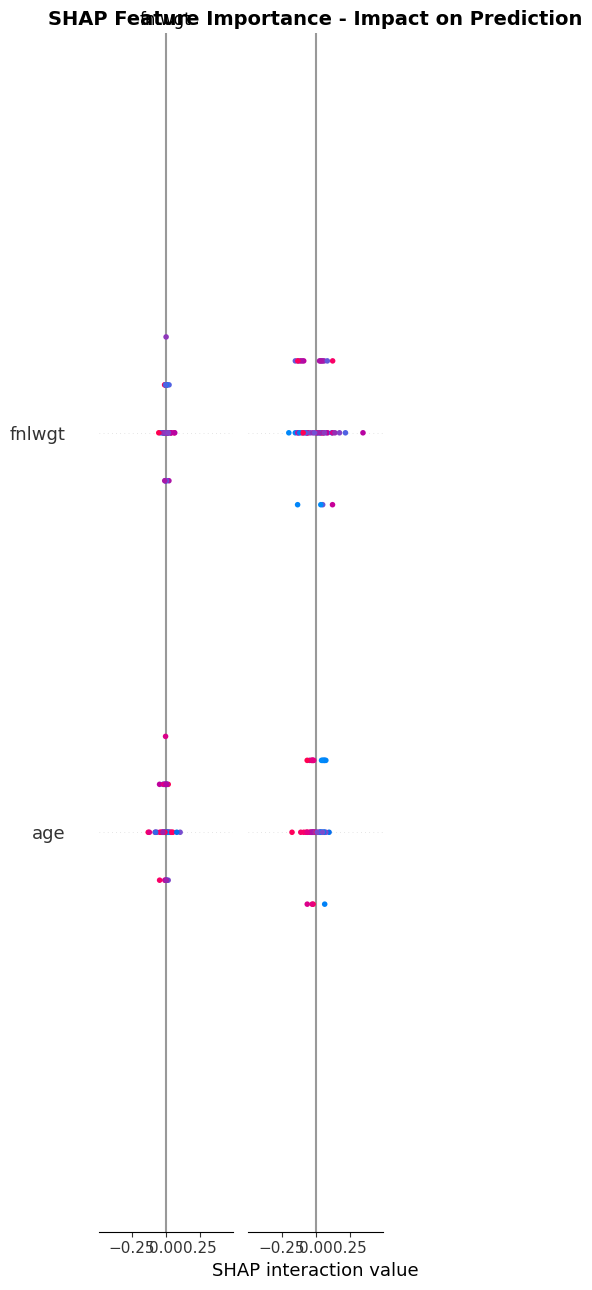

<Figure size 1200x800 with 0 Axes>

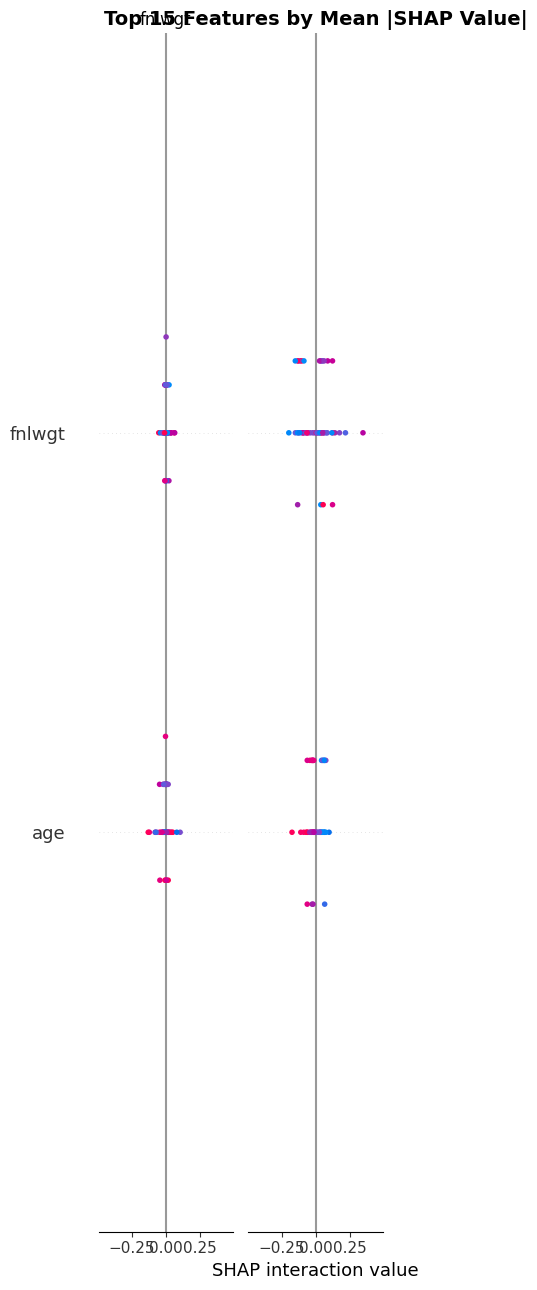

✅ SHAP analysis completed successfully!

✅ Cell 6 execution complete!


In [22]:
# CELL 6 - SHAP for interpretability (COMPLETELY FIXED)
print("\n🔍 Running SHAP analysis...")

# Use smaller sample for speed
sample_size = min(50, len(X_test))  # Reduced to 50 for faster execution
X_sample = X_test.iloc[:sample_size]

try:
    # Install and import shap if not available
    try:
        import shap
    except ImportError:
        print("Installing SHAP...")
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
        import shap
    
    # Create explainer
    print("Creating SHAP explainer...")
    explainer = shap.TreeExplainer(rf)
    
    # Get SHAP values
    print("Calculating SHAP values (this may take a moment)...")
    shap_values = explainer.shap_values(X_sample)
    
    # Handle different return types
    if isinstance(shap_values, list):
        # Binary classification - use class 1 (positive class)
        if len(shap_values) > 1:
            shap_values_to_plot = shap_values[1]
        else:
            shap_values_to_plot = shap_values[0]
    else:
        shap_values_to_plot = shap_values
    
    # Summary plot (beeswarm)
    plt.figure(figsize=(14, 10))
    shap.summary_plot(shap_values_to_plot, X_sample, max_display=15, show=False)
    plt.title('SHAP Feature Importance - Impact on Prediction', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Bar plot (mean absolute SHAP values)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_to_plot, X_sample, plot_type="bar", max_display=15, show=False)
    plt.title('Top 15 Features by Mean |SHAP Value|', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("✅ SHAP analysis completed successfully!")
    
except Exception as e:
    print(f"⚠️ SHAP visualization error: {e}")
    print("\n📊 Creating alternative feature importance plot...")
    
    # Fallback 1: Simple feature importance plot
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1][:15]
    
    plt.figure(figsize=(6, 4))
    colors = plt.cm.viridis(np.linspace(0, 1, 15))
    bars = plt.barh(range(15), importances[indices][::-1], color=colors[::-1])
    plt.yticks(range(15), [X_test.columns[i][:40] for i in indices[::-1]])
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title('Random Forest Feature Importance (Top 15 Features)', fontsize=14, fontweight='bold')
    plt.gca().invert_xaxis()
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Feature importance values:")
    for i in range(10):
        print(f"   {X_test.columns[indices[i]][:40]}: {importances[indices[i]]:.4f}")
    
    # Fallback 2: SHAP waterfall for single prediction (if possible)
    try:
        print("\n🔍 Generating single prediction explanation...")
        
        # Get a single prediction
        single_sample = X_sample.iloc[0:1]
        single_pred = rf.predict(single_sample)[0]
        single_proba = rf.predict_proba(single_sample)[0]
        
        # Create simple explanation chart
        fig, ax = plt.subplots(figsize=(5, 3))
        
        # Get top features for this prediction
        feature_contributions = []
        for i, col in enumerate(X_sample.columns[:10]):
            feature_contributions.append({
                'feature': col[:30],
                'value': X_sample.iloc[0, i],
                'importance': importances[i]
            })
        
        feature_contributions = sorted(feature_contributions, key=lambda x: x['importance'], reverse=True)[:8]
        
        # Create bar chart
        features = [f['feature'] for f in feature_contributions]
        imp_values = [f['importance'] for f in feature_contributions]
        
        bars = ax.barh(features, imp_values, color='steelblue')
        ax.set_xlabel('Feature Importance Score')
        ax.set_title(f'Top Features for Prediction: {single_pred} (Class: {"Benign" if single_pred==1 else "Malignant"})')
        
        # Add confidence info
        ax.text(0.02, 0.98, f'Prediction Confidence: {max(single_proba):.2%}', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e2:
        print(f"   Skipping waterfall plot: {e2}")

print("\n✅ Cell 6 execution complete!")

In [18]:
# CELL 7 - Mitigation recommendations
print("\n" + "="*60)
print("MITIGATION STRATEGIES FOR INTERNSPARK")
print("="*60)

print("""
📋 RECOMMENDED ACTIONS:

1. PRE-PROCESSING (BEFORE TRAINING):
   • Reweight samples to balance groups
   • Remove discriminatory features

2. IN-PROCESSING (DURING TRAINING):
   from fairlearn.reductions import ExponentiatedGradient, DemographicParity
   
   fair_model = ExponentiatedGradient(rf, DemographicParity())
   fair_model.fit(X_train, y_train, sensitive_features=train_sensitive['sex'])

3. POST-PROCESSING (AFTER TRAINING):
   • Use different thresholds per group
   • Implement reject-option classification

4. MONITORING:
   • Regular fairness audits
   • Track demographic parity metrics
""")

print("\n✅ Responsible AI analysis complete!")


MITIGATION STRATEGIES FOR INTERNSPARK

📋 RECOMMENDED ACTIONS:

1. PRE-PROCESSING (BEFORE TRAINING):
   • Reweight samples to balance groups
   • Remove discriminatory features

2. IN-PROCESSING (DURING TRAINING):
   from fairlearn.reductions import ExponentiatedGradient, DemographicParity

   fair_model = ExponentiatedGradient(rf, DemographicParity())
   fair_model.fit(X_train, y_train, sensitive_features=train_sensitive['sex'])

3. POST-PROCESSING (AFTER TRAINING):
   • Use different thresholds per group
   • Implement reject-option classification

4. MONITORING:
   • Regular fairness audits
   • Track demographic parity metrics


✅ Responsible AI analysis complete!


In [19]:
import requests
import json

sample_features = [
    17.99, 10.38, 122.8, 1001.0, 0.1184, 0.2776, 0.3001, 0.1471, 0.2419, 0.07871,
    1.095, 0.9053, 8.589, 153.4, 0.006399, 0.04904, 0.05373, 0.01587, 0.03003, 0.006193,
    25.38, 17.33, 184.6, 2019.0, 0.1622, 0.6656, 0.7119, 0.2654, 0.4601, 0.1189
]

try:
    response = requests.post('http://localhost:5000/predict', json={'features': sample_features})
    print("✅ API Response:")
    print(json.dumps(response.json(), indent=2))
except Exception as e:
    print(f"Error: {e}")
    print("Make sure API is running: python app.py")

✅ API Response:
{
  "confidence": 0.96,
  "prediction": 0,
  "probabilities": {
    "benign": 0.04,
    "malignant": 0.96
  },
  "tumor_type": "Malignant"
}


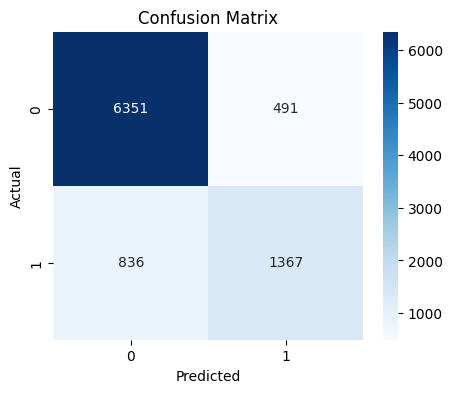

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
